# 10 — Ex-vivo model matching with DepMap/CCLE

This notebook performs a proof-of-concept matching between TCGA-BRCA molecular subtype expression profiles and DepMap/CCLE breast cancer cell line models.

The goal is to identify candidate ex-vivo models representing Basal-like, HER2-enriched and Luminal-like disease contexts.

This is an exploratory model-matching analysis, not an experimental validation.

In [20]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_context("notebook")

In [21]:
PROJECT_ROOT = Path("..").resolve()

DEPMAP_DIR = PROJECT_ROOT / "data" / "raw" / "depmap"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

tcga_expression_path = PROCESSED_DIR / "expression_rsem_samples_by_gene.tsv"
tcga_metadata_path = PROCESSED_DIR / "clinical_marker_analysis_table.tsv"

depmap_model_path = DEPMAP_DIR / "Model.csv"
depmap_expression_path = DEPMAP_DIR / "OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv"

print("TCGA expression:", tcga_expression_path.exists())
print("TCGA metadata:", tcga_metadata_path.exists())
print("DepMap model metadata:", depmap_model_path.exists())
print("DepMap expression:", depmap_expression_path.exists())

TCGA expression: True
TCGA metadata: True
DepMap model metadata: True
DepMap expression: True


In [22]:
tcga_expr = pd.read_csv(tcga_expression_path, sep="\t")
tcga_meta = pd.read_csv(tcga_metadata_path, sep="\t")

model_meta = pd.read_csv(depmap_model_path)
dep_expr = pd.read_csv(depmap_expression_path)

print("TCGA expression:", tcga_expr.shape)
print("TCGA metadata:", tcga_meta.shape)
print("DepMap model metadata:", model_meta.shape)
print("DepMap expression:", dep_expr.shape)

display(tcga_expr.head())
display(tcga_meta.head())
display(model_meta.head())
display(dep_expr.head())

TCGA expression: (1082, 20514)
TCGA metadata: (1082, 72)
DepMap model metadata: (2154, 49)
DepMap expression: (1775, 19221)


,SAMPLE_ID_ORIGINAL,SAMPLE_ID_15,PATIENT_ID_12,A1BG,A1CF,A2BP1,A2LD1,A2M,A2M-AS1,A2ML1,A4GALT,A4GNT,AAA1,AAAS,AACS,AACSL,AADAC,AADACL2,AADACL3,AADACL4,AADACP1,AADAT,AAGAB,AAK1,AAMP,AANAT,AARS,AARS2,AARSD1,AASDH,AASDHPPT,AASS,AATBC,AATF,AATK,ABAT,ABCA1,ABCA10,ABCA11P,ABCA12,ABCA13,ABCA17P,ABCA2,ABCA3,ABCA4,ABCA5,ABCA6,ABCA7,ABCA8,ABCA9,...,ZNRF2,ZNRF2P1,ZNRF3,ZNRF4,ZP1,ZP2,ZP3,ZP4,ZPBP,ZPBP2,ZPLD1,ZRANB1,ZRANB2,ZRANB3,ZRSR2,ZSCAN1,ZSCAN10,ZSCAN12,ZSCAN12P1,ZSCAN16,ZSCAN18,ZSCAN2,ZSCAN20,ZSCAN21,ZSCAN22,ZSCAN23,ZSCAN29,ZSCAN4,ZSCAN5A,ZSCAN5B,ZSWIM1,ZSWIM2,ZSWIM3,ZSWIM4,ZSWIM5,ZSWIM6,ZSWIM7,ZUFSP,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22
0,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,TCGA-3C-AAAU,197.090,0.0000,0.0000,102.9630,5798.37,32.2187,1.3786,68.2424,8.6165,0.3447,649.337,1087.400,1.3786,0.0000,0.0,0.0000,0.0,0.0000,5.5145,1300.40,517.333,2053.13,0.3447,4409.56,689.897,466.668,277.450,808.914,45.8396,111.6690,1518.91,619.5930,620.731,288.462,16.2334,79.1509,321.2220,0.0000,17.9223,4507.450,5470.770,3.7912,795.093,23.0921,596.9490,58.5920,37.5678,...,414.969,76.1696,741.706,0.0,3.7912,0.0000,411.791,0.0000,1.034,0.3447,53.7668,879.225,2504.080,72.0337,421.862,0.3447,2.7573,141.6550,128.1790,225.062,132.349,582.473,158.8880,253.510,300.887,38.2571,960.220,0.3447,32.3979,1.0340,431.513,0.3447,180.2570,489.416,454.9500,621.764,194.108,89.956,430.824,415.824,931.957,129.5920,1007.780,1658.500,258.4940,1208.370,3507.25,1894.930,1180.460,1.7233
1,TCGA-3C-AALI-01,TCGA-3C-AALI-01,TCGA-3C-AALI,237.384,0.0000,0.0000,70.8646,7571.98,29.9782,4.3502,157.6940,0.5438,0.0000,887.983,836.324,35.3453,1.0875,0.0,0.0000,0.0,0.0000,24.4698,3541.05,848.287,2979.88,2.1751,4570.96,472.501,418.706,184.339,678.630,71.7781,13.5943,7649.27,107.6670,240.348,421.930,17.9445,96.0903,678.6300,1.6313,70.6906,2330.070,2656.880,45.1332,388.798,25.0136,763.4580,20.1196,46.2208,...,841.218,39.6955,373.573,0.0,30.4513,4.3502,439.222,0.5438,0.000,2.1751,3.2626,566.068,627.656,62.5340,349.647,18.4883,0.0000,91.8978,58.2164,174.551,1549.760,236.542,27.7325,698.521,197.390,7.0691,588.363,0.0000,127.7870,4.3502,507.341,0.0000,139.2060,475.802,113.6490,242.523,217.134,105.492,340.402,1161.330,965.198,59.8151,448.613,1343.120,198.4770,603.589,5504.62,1318.650,406.743,926.5910
2,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,TCGA-3C-AALJ,423.237,0.9066,0.0000,161.2600,8840.40,17.2620,0.0000,573.8890,0.0000,0.0000,723.481,1533.090,2.7199,0.9066,0.0,1.8132,0.0,1.8132,53.4905,1360.83,568.450,2291.93,1.8132,2556.66,439.710,390.752,190.390,779.692,76.1559,20.8522,2097.91,145.0590,375.340,689.882,27.1985,156.0200,0.0000,0.9066,12.6927,3208.520,1514.050,1.8132,559.384,81.5956,383.5000,52.5839,54.3971,...,266.546,38.9846,257.480,0.0,2.7199,0.0000,334.506,0.0000,0.000,0.0000,117.8600,1125.110,1951.210,35.3581,470.535,112.4210,0.0000,99.7280,38.2684,110.607,2225.750,268.359,52.5839,282.865,138.713,46.2375,514.053,0.0000,62.5567,0.0000,352.675,0.0000,81.5956,485.947,180.4170,506.800,164.234,235.721,304.624,305.422,2531.280,35.3581,533.998,768.812,331.8220,532.185,5458.75,942.883,509.519,35.3581
3,TCGA-3C-AALK-01,TCGA-3C-AALK-01,TCGA-3C-AALK,191.018,0.0000,0.0000,62.5072,10960.20,17.8527,1.6549,506.4130,0.0000,0.0000,776.996,858.088,0.0000,2.8962,0.0,0.0000,0.0,1.2412,57.0956,1683.49,727.762,2762.52,0.4137,2122.88,431.936,493.587,196.525,665.288,183.2850,38.8912,1915.18,119.9840,1721.560,749.264,23.5830,137.3230,1430.7000,2.4824,9.1022,1375.260,968.556,73.2313,412.081,78.1961,465.8670,213.4880,70.3351,...,632.602,50.0621,330.161,0.0,1.2412,1.6549,127.017,0.4137,0.000,0.0000,9.1022,780.306,1195.830,61.2329,364.501,6.2060,0.8275,211.8330,33.4506,163.012,1276.380,304.923,36.8225,300.625,122.466,26.4791,409.185,0.4137,57.5093,0.8275,286.305,0.0000,67.0252,626.396,107.5710,340.505,196.136,148.531,314.026,394.506,668.597,55.0269,437.733,863.881,175.4240,607.365,5691.35,781.134,700.869,66.6115
4,TCGA-4H-AAAK-01,TCGA-4H-AAAK-01,TCGA-4H-AAAK,268.881,0.4255,3.8298,154.3700,9585.44,31.5787

,PATIENT_ID_sample,SAMPLE_ID,ONCOTREE_CODE,CANCER_TYPE,CANCER_TYPE_DETAILED,TUMOR_TYPE,GRADE,TISSUE_PROSPECTIVE_COLLECTION_INDICATOR,TISSUE_RETROSPECTIVE_COLLECTION_INDICATOR,TISSUE_SOURCE_SITE_CODE,TUMOR_TISSUE_SITE,ANEUPLOIDY_SCORE,SAMPLE_TYPE,MSI_SCORE_MANTIS,MSI_SENSOR_SCORE,SOMATIC_STATUS,TMB_NONSYNONYMOUS,TISSUE_SOURCE_SITE,TBL_SCORE,SAMPLE_ID_ORIGINAL_x,SAMPLE_ID_15,PATIENT_ID_12,PATIENT_ID_patient,SUBTYPE,CANCER_TYPE_ACRONYM,OTHER_PATIENT_ID,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS,ETHNICITY,FORM_COMPLETION_DATE,HISTORY_NEOADJUVANT_TRTYN,ICD_10,ICD_O_3_HISTOLOGY,ICD_O_3_SITE,INFORMED_CONSENT_VERIFIED,NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT,PATH_M_STAGE,PATH_N_STAGE,PATH_T_STAGE,PERSON_NEOPLASM_CANCER_STATUS,PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT,PRIOR_DX,RACE,RADIATION_THERAPY,WEIGHT,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS,GENETIC_ANCESTRY_LABEL,SAMPLE_ID_ORIGINAL_y,SAMPLE_ID_ORIGINAL,ESR1,PGR,ERBB2,MKI67,FOXA1,GATA3,TP53,PIK3CA,BRCA1,BRCA2
0,TCGA-3C-AAAU,TCGA-3C-AAAU-01,ILC,Breast Cancer,Breast Invasive Lobular Carcinoma,Infiltrating Lobular Carcinoma,NaN,No,Yes,3C,Breast,19.0,Primary,0.3319,0.55,Matched,0.800000,Columbia University,205.0,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,TCGA-3C-AAAU,TCGA-3C-AAAU,BRCA_LumA,BRCA,6E7D5EC6-A469-467C-B748-237353C23416,55,Female,STAGE X,6TH,4047.0,-20211.0,0,Not Hispanic Or Latino,1/13/14,No,C50.9,8520/3,C50.9,Yes,No,MX,NX,TX,With Tumor,Yes,No,White,No,NaN,Yes,0:LIVING,133.050597,0:ALIVE OR DEAD TUMOR FREE,133.050597,1:Recurred/Progressed,59.440444,1:PROGRESSION,59.440444,EUR,TCGA-3C-AAAU-01,TCGA-3C-AAAU-01,3457.9600,2273.2700,7113.41,2582.870,5448.37,14337.50,1385.530,487.003,831.317,178.878
1,TCGA-3C-AALI,TCGA-3C-AALI-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,22.0,Primary,0.3449,0.74,Matched,15.266667,Columbia University,190.0,TCGA-3C-AALI-01,TCGA-3C-AALI-01,TCGA-3C-AALI,TCGA-3C-AALI,BRCA_Her2,BRCA,55262FCB-1B01-4480-B322-36570430C917,50,Female,STAGE IIB,6TH,4005.0,-18538.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N1A,T2,Tumor Free,Yes,No,Black or African American,Yes,NaN,Yes,0:LIVING,131.669790,0:ALIVE OR DEAD TUMOR FREE,131.669790,0:DiseaseFree,131.669790,0:CENSORED,131.669790,AFR,TCGA-3C-AALI-01,TCGA-3C-AALI-01,68.5155,27.1887,194625.00,2285.480,6049.48,7437.74,414.356,321.914,389.886,153.888
2,TCGA-3C-AALJ,TCGA-3C-AALJ-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,13.0,Primary,0.3266,0.31,Matched,0.933333,Columbia University,365.0,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,TCGA-3C-AALJ,TCGA-3C-AALJ,BRCA_LumB,BRCA,427D0648-3F77-4FFC-B52C-89855426D647,62,Female,STAGE IIB,7TH,1474.0,-22848.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N1A,T2,Tumor Free,Yes,No,Black or African American,No,NaN,Yes,0:LIVING,48.459743,0:ALIVE OR DEAD TUMOR FREE,48.459743,0:DiseaseFree,48.459743,0:CENSORED,48.459743,AFR_ADMIX,TCGA-3C-AALJ-01,TCGA-3C-AALJ-01,7482.3200,473.8350,11070.70,949.229,4620.13,10252.90,1289.210,216.682,200.363,151.405
3,TCGA-3C-AALK,TCGA-3C-AALK-01,IDC,Breast Cancer,Breast Invasive Ductal Carcinoma,Infiltrating Ductal Carcinoma,NaN,No,Yes,3C,Breast,4.0,Primary,0.3218,0.03,Matched,1.500000,Columbia University,25.0,TCGA-3C-AALK-01,TCGA-3C-AALK-01,TCGA-3C-AALK,TCGA-3C-AALK,BRCA_LumA,BRCA,C31900A4-5DCD-4022-97AC-638E86E889E4,52,Female,STAGE IA,7TH,1448.0,-19074.0,0,Not Hispanic Or Latino,7/28/14,No,C50.9,8500/3,C50.9,Yes,No,M0,N0 (I+),T1C,Tumor Free,Yes,No,Black or African American,No,NaN,Yes,0:LIVING,47.604958,0:ALIVE OR DEAD TUMOR FREE,47.604958,NaN,NaN,0:CENSORED,47.604958,AFR,TCGA-3C-AALK-01,TCGA-3C-AALK-01,2485.3100,2236.4600,36022.80,1139.430,7352.09,8761.69,1418.290,326.024,148.118,102.193
4,TCGA-4H-AAAK,TCGA-4H-AAAK-01,ILC,Breast Cancer,Breast Invasive Lobular Carcinoma,

,ModelID,PatientID,CellLineName,StrippedCellLineName,DepmapModelType,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,OncotreeCode,PatientSubtypeFeatures,RRID,Age,AgeCategory,Sex,PatientRace,PrimaryOrMetastasis,SampleCollectionSite,SourceType,SourceDetail,CatalogNumber,ModelType,TissueOrigin,ModelDerivationMaterial,ModelTreatment,PatientTreatmentStatus,PatientTreatmentType,PatientTreatmentDetails,Stage,StagingSystem,PatientTumorGrade,PatientTreatmentResponse,GrowthPattern,OnboardedMedia,FormulationID,SerumFreeMedia,PlateCoating,EngineeredModel,EngineeredModelDetails,CulturedResistanceDrug,PublicComments,CCLEName,HCMIID,PediatricModelType,ModelAvailableInDbgap,ModelSubtypeFeatures,WTSIMasterCellID,SangerModelID,COSMICID,ModelIDAlias
0,ACH-000001,PT-gj46wT,NIH:OVCAR-3,NIHOVCAR3,HGSOC,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,HGSOC,NaN,CVCL_0465,60.0,Adult,Female,caucasian,Metastatic,ascites,ATCC,NaN,HTB-161,Cell Line,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adherent,MF-001-041,RPMI + 20% FBS + 0.01 mg/ml insulin,False,NaN,NaN,NaN,NaN,NaN,NIHOVCAR3_OVARY,NaN,False,Approved for public sharing - CCLE,NaN,2201.0,SIDM00105,905933.0,NaN
1,ACH-000002,PT-5qa3uk,HL-60,HL60,AMLMRC,Myeloid,Acute Myeloid Leukemia,AML with Myelodysplasia-Related Changes,AMLMRC,"TP53(del), CDKN2A and NRAS mutations [PubMed=2...",CVCL_0002,36.0,Adult,Female,caucasian,Primary,haematopoietic_and_lymphoid_tissue,ATCC,NaN,CCL-240,Cell Line,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Suspension,MF-005-001,IMDM + 10% FBS,False,NaN,NaN,NaN,NaN,NaN,HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NaN,True,Approved for public sharing - CCLE,"NRAS, BCOR and CDKN2A",55.0,SIDM00829,905938.0,NaN
2,ACH-000003,PT-puKIyc,CACO2,CACO2,COAD,Bowel,Colorectal Adenocarcinoma,Colon Adenocarcinoma,COAD,NaN,CVCL_0025,72.0,Adult,Male,caucasian,Primary,Colon,ATCC,NaN,HTB-37,Cell Line,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,Adherent,MF-015-009,EMEM + 20% FBS,False,NaN,NaN,NaN,NaN,NaN,CACO2_LARGE_INTESTINE,NaN,False,Approved for public sharing - CCLE,NaN,NaN,SIDM00891,NaN,NaN
3,ACH-000004,PT-q4K2cp,HEL,HEL,AMLNOS,Myeloid,Acute Myeloid Leukemia,"AML, NOS",AMLNOS,JAK2 and TP53 mutations,CVCL_0001,30.0,Adult,Male,caucasian,Primary,haematopoietic_and_lymphoid_tissue,DSMZ,NaN,ACC 11,Cell Line,NaN,NaN,NaN,Post-treatment,NaN,NaN,NaN,NaN,NaN,NaN,Suspension,MF-001-001,RPMI + 10% FBS,False,NaN,NaN,NaN,NaN,NaN,HEL_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NaN,True,Approved for public sharing - CCLE,JAK2 and TP53,783.0,SIDM00594,907053.0,NaN
4,ACH-000005,PT-q4K2cp,HEL 92.1.7,HEL9217,AML,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,AML,JAK2 and TP53 mutations,CVCL_2481,30.0,Adult,Male,caucasian,NaN,bone_marrow,ATCC,NaN,HEL9217,Cell Line,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mixed,MF-001-001,RPMI + 10% FBS,False,NaN,NaN,NaN,NaN,NaN,HEL9217_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NaN,True,Approved for public sharing - CCLE,NaN,NaN,SIDM00593,NaN,NaN


,Unnamed: 0,SequencingID,ModelConditionID,ModelID,IsDefaultEntryForMC,IsDefaultEntryForModel,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),FIRRM (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),NFYA (4800),STPG1 (90529),NIPAL3 (57185),LAS1L (81887),ENPP4 (22875),SEMA3F (6405),CFTR (1080),ANKIB1 (54467),CYP51A1 (1595),KRIT1 (889),RAD52 (5893),MYH16 (84176),BAD (572),LAP3 (51056),CD99 (4267),HS3ST1 (9957),AOC1 (26),WNT16 (51384),HECW1 (23072),MAD1L1 (8379),LASP1 (3927),SNX11 (29916),TMEM176A (55365),M6PR (4074),KLHL13 (90293),CYP26B1 (56603),ICA1 (3382),DBNDD1 (79007),ALS2 (57679),CASP10 (843),CFLAR (8837),TFPI (7035),NDUFAF7 (55471),RBM5 (10181),MTMR7 (9108),...,TOMT (120356740),CCDC39 (339829),OOSP1 (255649),UPK3BL2 (107983993),OOSP4A (112577462),ARHGAP11B (89839),OOSP3 (112577461),H2BK1 (114483833),FAM90A9 (441327),FAM90A16 (441323),FAM90A19 (728753),FAM90A22 (645558),FAM90A17 (728746),FAM90A23 (645572),FAM90A14 (645651),MSANTD5 (102724657),FAM90A18 (441326),FAM90A8 (441324),LCE7A (122526777),FAM90A10 (441328),FAM90A7 (441317),SPDYE15 (105180391),NOTCH2NLB (100996763),FAM246C (117134596),SPDYE13 (105180390),ASDURF (110599588),SMIM10L3 (122526779),SPEGNB (100996693),FAM246A (117134598),TMEM217B (121725057),NOTCH2NLR (101929796),SPADH (112577516),SPDYE14 (641776),DERPC (113455421),FAM246B (117134597),NOTCH2NLC (100996717),H3C2 (8358),SMIM40 (113523636),H3C3 (8352),CIMIP3 (114841037),ATXN8 (724066),SMIM42 (117981789),NPBWR1 (2831),ACTL10 (170487),RNF228 (122319436),PANO1 (101927423),HRURF (120766137),PRRC2B (84726),F8A2 (474383),F8A1 (8263)
0,0,CDS-010xbm,MC-001113-k2lR,ACH-001113,Yes,Yes,4.956577,0.000000,7.577648,3.179411,4.765742,0.037483,1.510547,3.103039,6.697482,4.852303,3.497101,4.253384,5.039358,2.873880,3.226268,0.000000,5.347148,6.964630,5.641245,3.706387,0.076894,5.585888,4.856592,5.698257,0.109176,0.108262,0.070586,2.993370,2.832289,5.417643,4.772382,0.000000,7.841401,5.586026,3.048822,1.852478,2.256235,5.235364,2.296314,5.424482,0.147443,4.783326,5.591937,0.832374,...,0.0,2.724965,0.000000,5.915177,0.0,1.577944,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.073702,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,1.550610,1.328480,0.000000,4.334225,0.0,0.291473,0.0,0.000000,2.713144,0.0,0.000000,4.395214,0.0,3.427618,2.763120,0.000000,0.093516,0.0,0.0,0.0,0.414727,0.077634,1.113094,0.411901,0.0,5.134808,1.214541,4.315653
1,1,CDS-02TzJp,MC-001289-BpdI,ACH-001289,Yes,Yes,4.955015,0.617117,7.333933,2.782935,3.735371,0.000000,0.148922,3.855123,4.376707,3.465922,1.977529,3.223240,4.790318,4.280221,1.461932,0.029911,5.339879,7.363749,5.034238,2.834440,0.000000,6.156269,6.250412,6.424030,0.098424,0.012832,0.384175,0.185485,2.756097,4.937071,4.671044,0.067118,7.406350,2.988092,0.145051,3.535356,4.359064,4.710063,0.435838,4.824844,0.018237,4.119813,6.323073,3.343402,...,0.0,1.978931,0.000000,1.061479,0.0,2.116351,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,3.996949,0.226760,0.000000,3.706287,0.0,0.000000,0.0,0.000000,0.066458,0.0,0.000000,4.055838,0.0,6.240925,1.320074,0.120649,0.671615,0.0,0.0,0.0,0.029809,0.000000,1.269267,1.026807,0.0,5.953793,0.006969,4.250636
2,2,CDS-0693hw,MC-001339-5nRN,ACH-001339,Yes,Yes,3.421952,0.000000,7.546069,2.615880,4.476233,0.064571,1.397491,6.833915,3.980336,3.437155,3.078680,3.620422,4.155158,1.102793,0.262396,0.064436,4.340797,5.904043,4.955987,2.506747,0.003578,5.096717,6.269128,8.173098,0.502299,0.093720,0.121218,0.091250,5.853013,6.467333,4.636549,0.194153,7.684728,0.162308,0.583182,2.395082,3.734113,4.330745,1.269165,5.080769,4.463433,3.937994,5.248755,0.791867,...,0.0,1.068072,0.436711,1.403960,0.0,1.872545,0.249546,0.0,0.009294,0.0,0.008273,0.0,0.0,0.000000,0.0,0.0,0.008273,0.0,0.0,0.0,0.0,0.002613,3.096544,0.060576,0.002613,2.108692,0.0,0.000000,0.0,0.000000,3.064350,0.0,0.002613,3.828439,0.0,4.292436,0.627906,0.867237,0.689369,0.0,0.0,0.0,0.127768,0.105594,0.413829,0.540575,0.0,4.205971,0.030894,2.783448
3,3,CDS-07Plat,MC-001619-

In [23]:
id_cols = ["SAMPLE_ID_15", "PATIENT_ID_12"]

tcga_meta = tcga_meta.drop_duplicates(subset=id_cols).copy()

tcga_df = tcga_expr.merge(
    tcga_meta[id_cols + ["SUBTYPE"]],
    on=id_cols,
    how="inner"
)

tcga_df = tcga_df[tcga_df["SUBTYPE"].notna()].copy()

non_gene_cols = [
    "SAMPLE_ID",
    "SAMPLE_ID_ORIGINAL",
    "SAMPLE_ID_15",
    "PATIENT_ID_12",
    "SUBTYPE",
]

tcga_gene_cols = [
    col for col in tcga_df.columns
    if col not in non_gene_cols
]

tcga_X_raw = tcga_df[tcga_gene_cols].apply(pd.to_numeric, errors="coerce")
tcga_X_raw = tcga_X_raw.fillna(tcga_X_raw.median(axis=0))

tcga_X_log = np.log2(tcga_X_raw + 1)

tcga_subtypes = tcga_df["SUBTYPE"].copy()

print("TCGA expression matrix:", tcga_X_log.shape)
display(tcga_subtypes.value_counts())

TCGA expression matrix: (981, 20511)


SUBTYPE
BRCA_LumA      499
BRCA_LumB      197
BRCA_Basal     171
BRCA_Her2       78
BRCA_Normal     36
Name: count, dtype: int64

In [24]:
import re

# Reload fresh, because previous dep_expr may already have been modified
dep_expr_raw = pd.read_csv(depmap_expression_path, low_memory=False)

print("Raw DepMap expression:", dep_expr_raw.shape)
display(dep_expr_raw.iloc[:5, :8])
display(dep_expr_raw.columns[:20].tolist())

# Detect the column containing DepMap model IDs such as ACH-000017
id_match_counts = {}

for col in dep_expr_raw.columns:
    values = dep_expr_raw[col].astype(str)
    id_match_counts[col] = values.str.match(r"^ACH-\d{6}$").sum()

id_match_counts = pd.Series(id_match_counts).sort_values(ascending=False)

display(id_match_counts.head(10))

depmap_id_col = id_match_counts.index[0]

if id_match_counts.iloc[0] == 0:
    raise ValueError("Could not detect a DepMap model ID column with ACH-xxxxxx values.")

print("Detected DepMap ID column:", depmap_id_col)

# Keep only gene-expression columns.
# DepMap gene columns usually look like: ERBB2 (2064), ESR1 (2099), etc.
gene_like_cols = [
    col for col in dep_expr_raw.columns
    if re.search(r" \(\d+\)$", str(col))
]

print("Gene-like expression columns:", len(gene_like_cols))
print(gene_like_cols[:10])

dep_expr = dep_expr_raw[[depmap_id_col] + gene_like_cols].copy()
dep_expr = dep_expr.set_index(depmap_id_col)
dep_expr.index = dep_expr.index.astype(str)

# Clean gene names: "ERBB2 (2064)" -> "ERBB2"
dep_expr.columns = (
    dep_expr.columns
    .astype(str)
    .str.replace(r" \(\d+\)$", "", regex=True)
    .str.strip()
)

# Convert expression values to numeric
dep_expr = dep_expr.apply(pd.to_numeric, errors="coerce")

# Drop columns that are entirely missing after conversion
dep_expr = dep_expr.dropna(axis=1, how="all")

# Collapse duplicated gene symbols, if any
dep_expr = dep_expr.T.groupby(level=0).median().T

print("Clean DepMap expression matrix:", dep_expr.shape)
display(dep_expr.iloc[:5, :5])
print("Example model IDs:", dep_expr.index[:5].tolist())

Raw DepMap expression: (1775, 19221)


,Unnamed: 0,SequencingID,ModelConditionID,ModelID,IsDefaultEntryForMC,IsDefaultEntryForModel,TSPAN6 (7105),TNMD (64102)
0,0,CDS-010xbm,MC-001113-k2lR,ACH-001113,Yes,Yes,4.956577,0.000000
1,1,CDS-02TzJp,MC-001289-BpdI,ACH-001289,Yes,Yes,4.955015,0.617117
2,2,CDS-0693hw,MC-001339-5nRN,ACH-001339,Yes,Yes,3.421952,0.000000
3,3,CDS-07Plat,MC-001619-IR6I,ACH-001619,No,No,5.196729,0.000000
4,4,CDS-08FOcu,MC-001979-E3qW,ACH-001979,Yes,Yes,4.651643,0.000000


['Unnamed: 0',
 'SequencingID',
 'ModelConditionID',
 'ModelID',
 'IsDefaultEntryForMC',
 'IsDefaultEntryForModel',
 'TSPAN6 (7105)',
 'TNMD (64102)',
 'DPM1 (8813)',
 'SCYL3 (57147)',
 'FIRRM (55732)',
 'FGR (2268)',
 'CFH (3075)',
 'FUCA2 (2519)',
 'GCLC (2729)',
 'NFYA (4800)',
 'STPG1 (90529)',
 'NIPAL3 (57185)',
 'LAS1L (81887)',
 'ENPP4 (22875)']

ModelID           1775
Unnamed: 0           0
DSCAM (1826)         0
PTCRA (171558)       0
PIK3CD (5293)        0
ZNF274 (10782)       0
CXXC5 (51523)        0
CLSTN1 (22883)       0
NMUR1 (10316)        0
DNAI2 (64446)        0
dtype: int64

Detected DepMap ID column: ModelID
Gene-like expression columns: 19215
['TSPAN6 (7105)', 'TNMD (64102)', 'DPM1 (8813)', 'SCYL3 (57147)', 'FIRRM (55732)', 'FGR (2268)', 'CFH (3075)', 'FUCA2 (2519)', 'GCLC (2729)', 'NFYA (4800)']
Clean DepMap expression matrix: (1775, 19215)


,A1BG,A1CF,A2M,A2ML1,A3GALT2
ModelID,,,,,
ACH-001113,3.603846,0.016489,0.142428,0.795040,0.0
ACH-001289,1.892729,0.000000,0.783477,0.047957,0.0
ACH-001339,2.650987,0.000000,5.890230,0.000000,0.0
ACH-001619,5.136671,0.000000,0.000000,0.000000,0.0
ACH-001979,2.083646,0.000000,10.249054,0.000000,0.0


Example model IDs: ['ACH-001113', 'ACH-001289', 'ACH-001339', 'ACH-001619', 'ACH-001979']


In [25]:
display(model_meta.columns.tolist())

['ModelID',
 'PatientID',
 'CellLineName',
 'StrippedCellLineName',
 'DepmapModelType',
 'OncotreeLineage',
 'OncotreePrimaryDisease',
 'OncotreeSubtype',
 'OncotreeCode',
 'PatientSubtypeFeatures',
 'RRID',
 'Age',
 'AgeCategory',
 'Sex',
 'PatientRace',
 'PrimaryOrMetastasis',
 'SampleCollectionSite',
 'SourceType',
 'SourceDetail',
 'CatalogNumber',
 'ModelType',
 'TissueOrigin',
 'ModelDerivationMaterial',
 'ModelTreatment',
 'PatientTreatmentStatus',
 'PatientTreatmentType',
 'PatientTreatmentDetails',
 'Stage',
 'StagingSystem',
 'PatientTumorGrade',
 'PatientTreatmentResponse',
 'GrowthPattern',
 'OnboardedMedia',
 'FormulationID',
 'SerumFreeMedia',
 'PlateCoating',
 'EngineeredModel',
 'EngineeredModelDetails',
 'CulturedResistanceDrug',
 'PublicComments',
 'CCLEName',
 'HCMIID',
 'PediatricModelType',
 'ModelAvailableInDbgap',
 'ModelSubtypeFeatures',
 'WTSIMasterCellID',
 'SangerModelID',
 'COSMICID',
 'ModelIDAlias']

In [26]:
# Collapse duplicated model IDs, if any
n_duplicated_models = dep_expr.index.duplicated().sum()
print("Duplicated model IDs in DepMap expression:", n_duplicated_models)

if n_duplicated_models > 0:
    dep_expr = dep_expr.groupby(dep_expr.index).median()

print("DepMap expression after collapsing duplicated model IDs:", dep_expr.shape)

Duplicated model IDs in DepMap expression: 56
DepMap expression after collapsing duplicated model IDs: (1719, 19215)


In [27]:
# Filter breast cancer cell line models using curated metadata fields

breast_meta = model_meta[
    model_meta["OncotreeLineage"]
    .astype(str)
    .str.fullmatch("Breast", case=False, na=False)
].copy()

# Remove non-cancerous models if present
if "OncotreePrimaryDisease" in breast_meta.columns:
    breast_meta = breast_meta[
        ~breast_meta["OncotreePrimaryDisease"]
        .astype(str)
        .str.contains("Non-Cancerous", case=False, na=False)
    ].copy()

# Keep cell lines only, if column exists
if "ModelType" in breast_meta.columns:
    breast_meta = breast_meta[
        breast_meta["ModelType"]
        .astype(str)
        .str.contains("Cell Line", case=False, na=False)
    ].copy()

print("Breast cancer cell line models:", breast_meta.shape)

display(
    breast_meta[
        [
            col for col in [
                "ModelID",
                "CellLineName",
                "StrippedCellLineName",
                "OncotreeLineage",
                "OncotreePrimaryDisease",
                "OncotreeSubtype",
                "ModelSubtypeFeatures",
                "CCLEName",
            ]
            if col in breast_meta.columns
        ]
    ].head(20)
)

Breast cancer cell line models: (87, 49)


,ModelID,CellLineName,StrippedCellLineName,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,ModelSubtypeFeatures,CCLEName
15,ACH-000017,SK-BR-3,SKBR3,Breast,Invasive Breast Carcinoma,Invasive Breast Carcinoma,HER2+,SKBR3_BREAST
17,ACH-000019,MCF-7,MCF7,Breast,Invasive Breast Carcinoma,Invasive Breast Carcinoma,ER+,MCF7_BREAST
26,ACH-000028,KPL-1,KPL1,Breast,Invasive Breast Carcinoma,Invasive Breast Carcinoma,ER+,KPL1_BREAST
42,ACH-000044,MDA-MB-134-VI,MDAMB134VI,Breast,Invasive Breast Carcinoma,Breast Invasive Lobular Carcinoma,luminal ER+,MDAMB134VI_BREAST
95,ACH-000097,ZR-75-1,ZR751,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,"luminal ER, PR+",ZR751_BREAST
109,ACH-000111,HCC1187,HCC1187,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,basal_A TNBC,HCC1187_BREAST
115,ACH-000117,EFM-192A,EFM192A,Breast,Invasive Breast Carcinoma,Invasive Breast Carcinoma,HER2+,EFM192A_BREAST
145,ACH-000147,T-47D,T47D,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,"luminal ER, PR+",T47D_BREAST
146,ACH-000148,Hs 578T,HS578T,Breast,Invasive Breast Carcinoma,"Breast Invasive Carcinoma, NOS",basal_B TNBC,HS578T_BREAST
194,ACH-000196,HCC1599,HCC1599,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,basal_A TNBC,HCC1599_BREAST


In [28]:
id_col_meta = "ModelID"

breast_ids = breast_meta[id_col_meta].astype(str)

overlap = sorted(
    set(breast_ids)
    .intersection(set(dep_expr.index.astype(str)))
)

print("Overlap breast metadata vs expression:", len(overlap))
print("Example overlap IDs:", overlap[:10])

if len(overlap) == 0:
    print("Example breast ModelIDs:", breast_ids.head(10).tolist())
    print("Example expression IDs:", dep_expr.index[:10].tolist())
    raise ValueError("No overlap between breast metadata ModelID and expression matrix index.")

dep_breast_expr = dep_expr.loc[overlap].copy()

print("DepMap breast expression:", dep_breast_expr.shape)
display(dep_breast_expr.iloc[:5, :5])

Overlap breast metadata vs expression: 70
Example overlap IDs: ['ACH-000017', 'ACH-000019', 'ACH-000028', 'ACH-000044', 'ACH-000097', 'ACH-000111', 'ACH-000117', 'ACH-000147', 'ACH-000148', 'ACH-000196']
DepMap breast expression: (70, 19215)


,A1BG,A1CF,A2M,A2ML1,A3GALT2
ModelID,,,,,
ACH-000017,3.026251,0.016191,0.188368,3.074132,0.0
ACH-000019,3.359517,0.012027,0.322191,0.066011,0.0
ACH-000028,3.875583,0.016448,0.399194,0.000000,0.0
ACH-000044,5.287624,0.071363,0.420614,0.383522,0.0
ACH-000097,5.289060,0.089208,0.219805,0.000000,0.0


In [29]:
print("Selected metadata ID column:", id_col_meta)
print("Breast metadata:", breast_meta.shape)
print("Breast expression:", dep_breast_expr.shape)

assert id_col_meta == "ModelID"
assert dep_breast_expr.shape[0] > 0
assert dep_breast_expr.shape[1] > 1000

Selected metadata ID column: ModelID
Breast metadata: (87, 49)
Breast expression: (70, 19215)


In [30]:
common_genes = sorted(set(tcga_X_log.columns).intersection(set(dep_breast_expr.columns)))

print("Common genes:", len(common_genes))
print(common_genes[:20])

Common genes: 16412
['A1BG', 'A1CF', 'A2M', 'A2ML1', 'A4GALT', 'A4GNT', 'AAAS', 'AACS', 'AADAC', 'AADACL2', 'AADACL3', 'AADACL4', 'AADAT', 'AAGAB', 'AAK1', 'AAMP', 'AANAT', 'AARS2', 'AARSD1', 'AASDH']


In [31]:
# Use top variable genes in TCGA among genes shared with DepMap
tcga_common = tcga_X_log[common_genes].copy()
dep_common = dep_breast_expr[common_genes].copy()

gene_variance = tcga_common.var(axis=0).sort_values(ascending=False)

n_signature_genes = min(3000, len(gene_variance))
signature_genes = gene_variance.head(n_signature_genes).index.tolist()

print("Signature genes used for matching:", len(signature_genes))

tcga_sig = tcga_common[signature_genes].copy()
dep_sig = dep_common[signature_genes].copy()

Signature genes used for matching: 3000


In [32]:
def zscore_columns(df):
    return (df - df.mean(axis=0)) / df.std(axis=0).replace(0, np.nan)


tcga_z = zscore_columns(tcga_sig)
dep_z = zscore_columns(dep_sig)

tcga_z = tcga_z.fillna(0)
dep_z = dep_z.fillna(0)

print("TCGA z:", tcga_z.shape)
print("DepMap z:", dep_z.shape)

TCGA z: (981, 3000)
DepMap z: (70, 3000)


In [33]:
tcga_z_with_subtype = tcga_z.copy()
tcga_z_with_subtype["SUBTYPE"] = tcga_subtypes.values

subtype_centroids = (
    tcga_z_with_subtype
    .groupby("SUBTYPE")
    .mean()
)

display(subtype_centroids)

,CLEC3A,CPB1,SCGB2A2,SCGB1D2,TFF1,GSTM1,PIP,S100A7,MUCL1,ANKRD30A,KCNJ3,CYP4Z1,PRAME,AGR3,HMGCS2,SERPINA6,TFAP2B,MUC6,DHRS2,SLC30A8,UGT2B11,VSTM2A,TAT,ADH1B,ADIPOQ,COL2A1,CALML5,MYBPC1,GABRP,GP2,MUC5B,CEACAM5,KRT14,TFF3,GRIA2,SYT13,SOX10,KRT5,CRABP1,BMPR1B,CST9,LTF,STAC2,KRT6B,HOXB13,CYP2A6,NPY1R,KLK11,FABP7,CRISP3,...,CYP2D6,ACSM5,FHL1,PRR18,TTLL9,SIGLEC8,PCDH7,AK4,ITIH4,UNC13D,ELOVL4,ZDHHC15,WNT9A,FLRT2,GPLD1,PAMR1,IRAK3,KRT19,SV2A,PRDM13,NOXA1,DEPDC1,CHN2,TMEM52,PDE5A,GPM6B,FRMD5,SP140,TPPP3,MAGEB1,ZNF114,GPX3,CENPA,GADD45G,CFP,RHOV,MYOCD,BIRC3,HGF,PRKACB,ITM2A,CHADL,SLC26A5,SMOC2,PLEKHH2,EFCAB6,TBX4,KCNJ15,EFHB,DUSP26
SUBTYPE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
BRCA_Basal,-0.668863,-0.825756,-1.012438,-0.929758,-1.551824,-0.291312,-1.082567,0.406526,-0.577545,-1.351196,-0.940681,-0.968088,0.956342,-1.664271,-1.036830,-0.713928,-0.756645,-0.491008,-1.056737,-0.817197,-0.714155,-0.659711,-0.636087,-0.503459,-0.478310,0.245877,0.533766,0.213193,1.314678,-1.366775,0.533603,-1.130207,0.492898,-1.701021,-0.395047,-0.424362,0.980753,0.768565,0.994966,-0.737811,-0.918156,0.076495,0.731520,1.107973,0.289368,-0.641440,-0.451498,0.294724,1.124222,-0.456274,...,0.619651,-0.840200,-0.372313,1.046308,-0.759725,-0.909503,-0.628160,0.503691,-0.225023,0.913009,0.844330,-0.058993,-0.230815,-0.349051,0.256763,-0.459078,-0.119039,-0.620567,-0.125905,1.428186,-0.736222,1.062155,-1.137572,0.576029,-0.523417,1.140478,0.455992,0.332422,-0.710719,1.130944,0.316029,0.086008,1.233686,-0.674021,0.153036,0.319789,-0.576200,0.461955,-0.654026,-0.221187,-0.345553,-0.234346,-0.561134,-0.982269,-0.340442,-1.331597,0.521739,0.290299,-0.536324,0.008539
BRCA_Her2,0.127426,-0.670810,0.206814,-0.042664,-0.440956,-0.147357,0.340469,0.829573,1.062928,-0.111707,-0.505413,0.333328,0.200895,-0.890670,0.271146,-0.788179,0.701233,0.582801,0.168108,-0.171692,0.767797,-0.319403,0.014613,-0.346479,-0.326896,-0.658334,0.791455,-0.094688,-0.489238,-0.178505,0.093448,0.516145,-0.536903,0.025469,-0.693991,-0.149077,-0.699464,-0.335544,-0.023142,-0.705144,-0.863663,0.240218,0.245504,-0.328542,0.714682,-0.512367,-1.249676,-0.425625,0.553130,0.902646,...,0.032617,-0.201027,-0.239862,0.202757,-0.691361,0.265086,0.343265,0.742117,-0.062180,0.262642,-0.306939,-0.427836,-0.178250,-0.203419,-0.286488,-0.203413,-0.181201,-0.023697,-0.477531,-0.167685,-0.260169,0.486734,-0.015062,-0.346503,-0.384128,-0.192625,-0.277424,0.326109,-0.205838,-0.022316,-0.154823,-0.234154,0.580477,-0.093046,-0.130400,0.462521,-0.288343,0.012856,-0.260703,0.268822,-0.123166,-0.344223,-0.632482,-0.452842,-0.125686,-0.133788,-0.481111,0.231165,0.010656,-0.122134
BRCA_LumA,0.144941,0.325077,0.309818,0.316271,0.472062,0.117047,0.359321,-0.191378,0.065799,0.493622,0.225950,0.313516,-0.366701,0.546765,0.306296,0.305592,0.271286,0.109695,0.217618,0.256804,0.150606,0.143335,0.240714,0.309215,0.272184,-0.025164,-0.221124,0.104279,-0.139598,0.436052,-0.134562,0.193703,0.140529,0.449512,0.250354,0.111611,0.002632,0.038776,-0.255357,0.310662,0.363183,0.153729,-0.031903,-0.070694,-0.209004,0.265913,0.351398,0.086650,-0.266877,-0.070682,...,-0.135214,0.333814,0.251497,-0.294184,0.370537,0.232403,0.197522,-0.260540,0.137658,-0.204264,-0.201027,0.156687,0.092823,0.268235,-0.029843,0.300092,0.188891,0.181367,0.062573,-0.337321,0.347944,-0.574075,0.283248,-0.223622,0.211870,-0.173540,-0.036651,-0.168574,0.215080,-0.302066,-0.103810,0.104209,-0.636657,0.335753,0.083759,-0.049778,0.309965,-0.051429,0.272852,0.084375,0.217400,0.196951,0.303245,0.436533,0.185518,0.454201,-0.100263,-0.058389,0.205219,0.089931
BRCA_LumB,0.192267,0.179554,-0.067235,-0.036207,0.354903,-0.021396,-0.163172,-0.234237,-0.267910,-0.008591,0.514348,-0.140020,0.066514,0.467838,-0.090601,0.195904,-0.394582,-0.149872,0.304587,0.181227,-0.138363,0.384227,-0.148980,-0.317024,-0.220337,0.098823,-0.310834,-0.515518,-0.754426,0.202199,-0.140552,0.339475,-0.775049,0.359366,-0.005194,0.238527,-0.7768

In [34]:
def pearson_similarity_matrix(A, B):
    """
    A: samples x genes
    B: groups x genes
    returns: samples x groups Pearson correlation
    """
    A_values = A.values
    B_values = B.values

    A_centered = A_values - A_values.mean(axis=1, keepdims=True)
    B_centered = B_values - B_values.mean(axis=1, keepdims=True)

    numerator = A_centered @ B_centered.T
    denominator = np.sqrt(
        np.sum(A_centered ** 2, axis=1, keepdims=True)
        @ np.sum(B_centered ** 2, axis=1, keepdims=True).T
    )

    sim = numerator / denominator

    return pd.DataFrame(
        sim,
        index=A.index,
        columns=B.index,
    )


similarity = pearson_similarity_matrix(dep_z, subtype_centroids)

display(similarity.head())

similarity.to_csv(
    TABLES_DIR / "depmap_breast_cell_line_tcga_subtype_similarity.csv"
)

SUBTYPE,BRCA_Basal,BRCA_Her2,BRCA_LumA,BRCA_LumB,BRCA_Normal
ModelID,,,,,
ACH-000017,-0.015305,0.202957,-0.060318,0.036324,-0.009075
ACH-000019,-0.245774,-0.166450,0.178485,0.308117,-0.186231
ACH-000028,-0.204187,-0.058430,0.119078,0.272283,-0.171098
ACH-000044,-0.294828,-0.237127,0.254237,0.310756,-0.223100
ACH-000097,-0.220630,0.029146,0.132646,0.224236,-0.158974


In [35]:
similarity_reset = similarity.reset_index().rename(columns={similarity.index.name or "index": "model_id"})

# Fix first column name if needed
similarity_reset = similarity.reset_index()
similarity_reset.columns = ["model_id"] + similarity.columns.tolist()

breast_meta_for_merge = breast_meta.copy()
breast_meta_for_merge[id_col_meta] = breast_meta_for_merge[id_col_meta].astype(str)

similarity_reset["model_id"] = similarity_reset["model_id"].astype(str)

merged_similarity = breast_meta_for_merge.merge(
    similarity_reset,
    left_on=id_col_meta,
    right_on="model_id",
    how="inner"
)

print("Merged similarity table:", merged_similarity.shape)
display(merged_similarity.head())

Merged similarity table: (70, 55)


,ModelID,PatientID,CellLineName,StrippedCellLineName,DepmapModelType,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,OncotreeCode,PatientSubtypeFeatures,RRID,Age,AgeCategory,Sex,PatientRace,PrimaryOrMetastasis,SampleCollectionSite,SourceType,SourceDetail,CatalogNumber,ModelType,TissueOrigin,ModelDerivationMaterial,ModelTreatment,PatientTreatmentStatus,PatientTreatmentType,PatientTreatmentDetails,Stage,StagingSystem,PatientTumorGrade,PatientTreatmentResponse,GrowthPattern,OnboardedMedia,FormulationID,SerumFreeMedia,PlateCoating,EngineeredModel,EngineeredModelDetails,CulturedResistanceDrug,PublicComments,CCLEName,HCMIID,PediatricModelType,ModelAvailableInDbgap,ModelSubtypeFeatures,WTSIMasterCellID,SangerModelID,COSMICID,ModelIDAlias,model_id,BRCA_Basal,BRCA_Her2,BRCA_LumA,BRCA_LumB,BRCA_Normal
0,ACH-000017,PT-8CE6ah,SK-BR-3,SKBR3,BRCA,Breast,Invasive Breast Carcinoma,Invasive Breast Carcinoma,BRCA,NaN,CVCL_0033,43.0,Adult,Female,caucasian,Metastatic,pleural_effusion,ATCC,NaN,NaN,Cell Line,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mixed,MF-023-001,McCoy's 5A + 10% FBS,False,NaN,NaN,NaN,NaN,NaN,SKBR3_BREAST,NaN,False,Approved for public sharing - CCLE,HER2+,NaN,SIDM00897,NaN,NaN,ACH-000017,-0.015305,0.202957,-0.060318,0.036324,-0.009075
1,ACH-000019,PT-viJKnw,MCF-7,MCF7,BRCA,Breast,Invasive Breast Carcinoma,Invasive Breast Carcinoma,BRCA,NaN,CVCL_0031,69.0,Adult,Female,caucasian,Metastatic,pleural_effusion,ATCC,NaN,HTB-22,Cell Line,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adherent,MF-015-010,EMEM + 10% FBS + 0.01 mg/ml recombinant insulin,False,NaN,NaN,NaN,NaN,NaN,MCF7_BREAST,NaN,False,Approved for public sharing - CCLE,ER+,588.0,SIDM00148,905946.0,NaN,ACH-000019,-0.245774,-0.166450,0.178485,0.308117,-0.186231
2,ACH-000028,PT-viJKnw,KPL-1,KPL1,BRCA,Breast,Invasive Breast Carcinoma,Invasive Breast Carcinoma,BRCA,NaN,CVCL_2094,69.0,Adult,Female,caucasian,Metastatic,pleural_effusion,DSMZ,NaN,NaN,Cell Line,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adherent,MF-002-001,DMEM + 10% FBS,False,NaN,NaN,NaN,NaN,SNP fingerprinting confirms that this line is ...,KPL1_BREAST,NaN,False,Approved for public sharing - CCLE,ER+,NaN,SIDM00147,NaN,NaN,ACH-000028,-0.204187,-0.058430,0.119078,0.272283,-0.171098
3,ACH-000044,PT-HMBfbj,MDA-MB-134-VI,MDAMB134VI,ILC,Breast,Invasive Breast Carcinoma,Breast Invasive Lobular Carcinoma,ILC,NaN,CVCL_0617,47.0,Adult,Female,caucasian,Metastatic,pleural_effusion,ATCC,NaN,NaN,Cell Line,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adherent,MF-021-003,L-15 + 20% FBS,False,NaN,NaN,NaN,NaN,NaN,MDAMB134VI_BREAST,NaN,False,Approved for public sharing - CCLE,luminal ER+,NaN,SIDM00005,NaN,NaN,ACH-000044,-0.294828,-0.237127,0.254237,0.310756,-0.223100
4,ACH-000097,PT-k1TO7o,ZR-75-1,ZR751,IDC,Breast,Invasive Breast Carcinoma,Breast Invasive Ductal Carcinoma,IDC,NaN,CVCL_0588,63.0,Adult,Female,caucasian,Metastatic,ascites,ATCC,NaN,NaN,Cell Line,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adherent,MF-001-001,RPMI + 10% FBS,False,NaN,NaN,NaN,NaN,NaN,ZR751_BREAST,NaN,False,Approved for public sharing - CCLE,"luminal ER, PR+",NaN,SIDM00314,NaN,NaN,ACH-000097,-0.220630,0.029146,0.132646,0.224236,-0.158974


In [36]:
print("Duplicated ModelIDs after merge:", merged_similarity["ModelID"].duplicated().sum())

merged_similarity = merged_similarity.drop_duplicates(subset=["ModelID"]).copy()

print("Merged similarity table after deduplication:", merged_similarity.shape)

Duplicated ModelIDs after merge: 0
Merged similarity table after deduplication: (70, 55)


In [37]:
name_candidates = [
    "CellLineName",
    "StrippedCellLineName",
    "ModelName",
    "CCLEName",
    "ModelID",
    "DepMap_ID",
]

name_col = None

for col in name_candidates:
    if col in merged_similarity.columns:
        name_col = col
        break

print("Using name column:", name_col)

Using name column: CellLineName


In [38]:
subtype_cols = subtype_centroids.index.tolist()

top_matches = []

for subtype in subtype_cols:
    cols_to_show = [
        col for col in [
            name_col,
            "ModelID",
            "DepMap_ID",
            "OncotreeLineage",
            "OncotreeSubtype",
            "PrimaryDisease",
            subtype,
        ]
        if col in merged_similarity.columns
    ]
    
    top = (
        merged_similarity
        .sort_values(subtype, ascending=False)
        .head(10)[cols_to_show]
        .copy()
    )
    
    top["matched_tcga_subtype"] = subtype
    top_matches.append(top)
    
    print("\n", subtype)
    display(top)

top_matches_df = pd.concat(top_matches, axis=0)

top_matches_df.to_csv(
    TABLES_DIR / "depmap_top_breast_models_by_tcga_subtype_similarity.csv",
    index=False
)


 BRCA_Basal


,CellLineName,ModelID,OncotreeLineage,OncotreeSubtype,BRCA_Basal,matched_tcga_subtype
9,HCC1599,ACH-000196,Breast,Breast Invasive Ductal Carcinoma,0.360670,BRCA_Basal
29,HCC2157,ACH-000691,Breast,Breast Invasive Ductal Carcinoma,0.333514,BRCA_Basal
48,HCC1569,ACH-000930,Breast,Breast Invasive Ductal Carcinoma,0.331199,BRCA_Basal
64,COLO 824,ACH-001820,Breast,"Breast Neoplasm, NOS",0.309695,BRCA_Basal
20,HCC1143,ACH-000374,Breast,Breast Invasive Ductal Carcinoma,0.296871,BRCA_Basal
68,UACC-3199,ACH-002499,Breast,Breast Invasive Ductal Carcinoma,0.286982,BRCA_Basal
40,MDA-MB-468,ACH-000849,Breast,Invasive Breast Carcinoma,0.286561,BRCA_Basal
42,CAL-85-1,ACH-000857,Breast,Breast Invasive Ductal Carcinoma,0.278397,BRCA_Basal
11,HCC1937,ACH-000223,Breast,Breast Invasive Ductal Carcinoma,0.255351,BRCA_Basal
5,HCC1187,ACH-000111,Breast,Breast Invasive Ductal Carcinoma,0.230874,BRCA_Basal



 BRCA_Her2


,CellLineName,ModelID,OncotreeLineage,OncotreeSubtype,BRCA_Her2,matched_tcga_subtype
55,SUM-190PT,ACH-001393,Breast,Invasive Breast Carcinoma,0.302240,BRCA_Her2
22,UACC-893,ACH-000554,Breast,Breast Invasive Lobular Carcinoma,0.289096,BRCA_Her2
33,HCC202,ACH-000725,Breast,Breast Ductal Carcinoma In Situ,0.240597,BRCA_Her2
12,AU565,ACH-000248,Breast,Invasive Breast Carcinoma,0.234199,BRCA_Her2
43,HCC1954,ACH-000859,Breast,Breast Invasive Ductal Carcinoma,0.227886,BRCA_Her2
0,SK-BR-3,ACH-000017,Breast,Invasive Breast Carcinoma,0.202957,BRCA_Her2
34,HCC2218,ACH-000755,Breast,Breast Ductal Carcinoma In Situ,0.158886,BRCA_Her2
21,BT-20,ACH-000536,Breast,Breast Invasive Ductal Carcinoma,0.140883,BRCA_Her2
49,MDA-MB-361,ACH-000934,Breast,Invasive Breast Carcinoma,0.136670,BRCA_Her2
61,ACC-3133,ACH-001683,Breast,Breast Invasive Lobular Carcinoma,0.134690,BRCA_Her2



 BRCA_LumA


,CellLineName,ModelID,OncotreeLineage,OncotreeSubtype,BRCA_LumA,matched_tcga_subtype
69,BCK4,ACH-002921,Breast,Breast Invasive Lobular Carcinoma,0.403629,BRCA_LumA
18,HCC1500,ACH-000349,Breast,Breast Ductal Carcinoma In Situ,0.299527,BRCA_LumA
57,SUM-44PE,ACH-001395,Breast,Breast Invasive Lobular Carcinoma,0.274518,BRCA_LumA
3,MDA-MB-134-VI,ACH-000044,Breast,Breast Invasive Lobular Carcinoma,0.254237,BRCA_LumA
38,BT-483,ACH-000818,Breast,Breast Invasive Ductal Carcinoma,0.252756,BRCA_LumA
39,ZR-75-30,ACH-000828,Breast,Breast Invasive Lobular Carcinoma,0.222410,BRCA_LumA
23,UACC-812,ACH-000568,Breast,Breast Invasive Lobular Carcinoma,0.212421,BRCA_LumA
15,HCC1419,ACH-000277,Breast,Breast Invasive Ductal Carcinoma,0.204484,BRCA_LumA
37,CAMA-1,ACH-000783,Breast,Breast Invasive Lobular Carcinoma,0.195937,BRCA_LumA
7,T-47D,ACH-000147,Breast,Breast Invasive Ductal Carcinoma,0.186767,BRCA_LumA



 BRCA_LumB


,CellLineName,ModelID,OncotreeLineage,OncotreeSubtype,BRCA_LumB,matched_tcga_subtype
38,BT-483,ACH-000818,Breast,Breast Invasive Ductal Carcinoma,0.367471,BRCA_LumB
18,HCC1500,ACH-000349,Breast,Breast Ductal Carcinoma In Situ,0.336262,BRCA_LumB
69,BCK4,ACH-002921,Breast,Breast Invasive Lobular Carcinoma,0.330424,BRCA_LumB
3,MDA-MB-134-VI,ACH-000044,Breast,Breast Invasive Lobular Carcinoma,0.310756,BRCA_LumB
1,MCF-7,ACH-000019,Breast,Invasive Breast Carcinoma,0.308117,BRCA_LumB
37,CAMA-1,ACH-000783,Breast,Breast Invasive Lobular Carcinoma,0.291353,BRCA_LumB
19,HCC1428,ACH-000352,Breast,Invasive Breast Carcinoma,0.278760,BRCA_LumB
2,KPL-1,ACH-000028,Breast,Invasive Breast Carcinoma,0.272283,BRCA_LumB
15,HCC1419,ACH-000277,Breast,Breast Invasive Ductal Carcinoma,0.269449,BRCA_LumB
7,T-47D,ACH-000147,Breast,Breast Invasive Ductal Carcinoma,0.240191,BRCA_LumB



 BRCA_Normal


,CellLineName,ModelID,OncotreeLineage,OncotreeSubtype,BRCA_Normal,matched_tcga_subtype
50,SUM-102PT,ACH-001388,Breast,Breast Invasive Ductal Carcinoma,0.259706,BRCA_Normal
68,UACC-3199,ACH-002499,Breast,Breast Invasive Ductal Carcinoma,0.217996,BRCA_Normal
56,SUM-229PE,ACH-001394,Breast,Invasive Breast Carcinoma,0.213446,BRCA_Normal
42,CAL-85-1,ACH-000857,Breast,Breast Invasive Ductal Carcinoma,0.185089,BRCA_Normal
26,HCC1806,ACH-000624,Breast,Breast Ductal Carcinoma In Situ,0.173738,BRCA_Normal
40,MDA-MB-468,ACH-000849,Breast,Invasive Breast Carcinoma,0.166672,BRCA_Normal
53,SUM-159PT,ACH-001391,Breast,Invasive Breast Carcinoma,0.162903,BRCA_Normal
67,21MT-2,ACH-002401,Breast,Breast Invasive Ductal Carcinoma,0.160271,BRCA_Normal
8,Hs 578T,ACH-000148,Breast,"Breast Invasive Carcinoma, NOS",0.155870,BRCA_Normal
5,HCC1187,ACH-000111,Breast,Breast Invasive Ductal Carcinoma,0.152853,BRCA_Normal


In [39]:
similarity_only = merged_similarity[subtype_cols].copy()

merged_similarity["best_matching_tcga_subtype"] = similarity_only.idxmax(axis=1)
merged_similarity["best_similarity"] = similarity_only.max(axis=1)

summary_best = (
    merged_similarity
    .sort_values("best_similarity", ascending=False)
)

cols_to_show = [
    col for col in [
        name_col,
        "ModelID",
        "DepMap_ID",
        "OncotreeLineage",
        "OncotreeSubtype",
        "PrimaryDisease",
        "best_matching_tcga_subtype",
        "best_similarity",
    ]
    if col in summary_best.columns
]

display(summary_best[cols_to_show].head(30))

summary_best.to_csv(
    TABLES_DIR / "depmap_breast_models_best_tcga_subtype_match.csv",
    index=False
)

,CellLineName,ModelID,OncotreeLineage,OncotreeSubtype,best_matching_tcga_subtype,best_similarity
69,BCK4,ACH-002921,Breast,Breast Invasive Lobular Carcinoma,BRCA_LumA,0.403629
38,BT-483,ACH-000818,Breast,Breast Invasive Ductal Carcinoma,BRCA_LumB,0.367471
9,HCC1599,ACH-000196,Breast,Breast Invasive Ductal Carcinoma,BRCA_Basal,0.360670
18,HCC1500,ACH-000349,Breast,Breast Ductal Carcinoma In Situ,BRCA_LumB,0.336262
29,HCC2157,ACH-000691,Breast,Breast Invasive Ductal Carcinoma,BRCA_Basal,0.333514
48,HCC1569,ACH-000930,Breast,Breast Invasive Ductal Carcinoma,BRCA_Basal,0.331199
3,MDA-MB-134-VI,ACH-000044,Breast,Breast Invasive Lobular Carcinoma,BRCA_LumB,0.310756
64,COLO 824,ACH-001820,Breast,"Breast Neoplasm, NOS",BRCA_Basal,0.309695
1,MCF-7,ACH-000019,Breast,Invasive Breast Carcinoma,BRCA_LumB,0.308117
55,SUM-190PT,ACH-001393,Breast,Invasive Breast Carcinoma,BRCA_Her2,0.302240


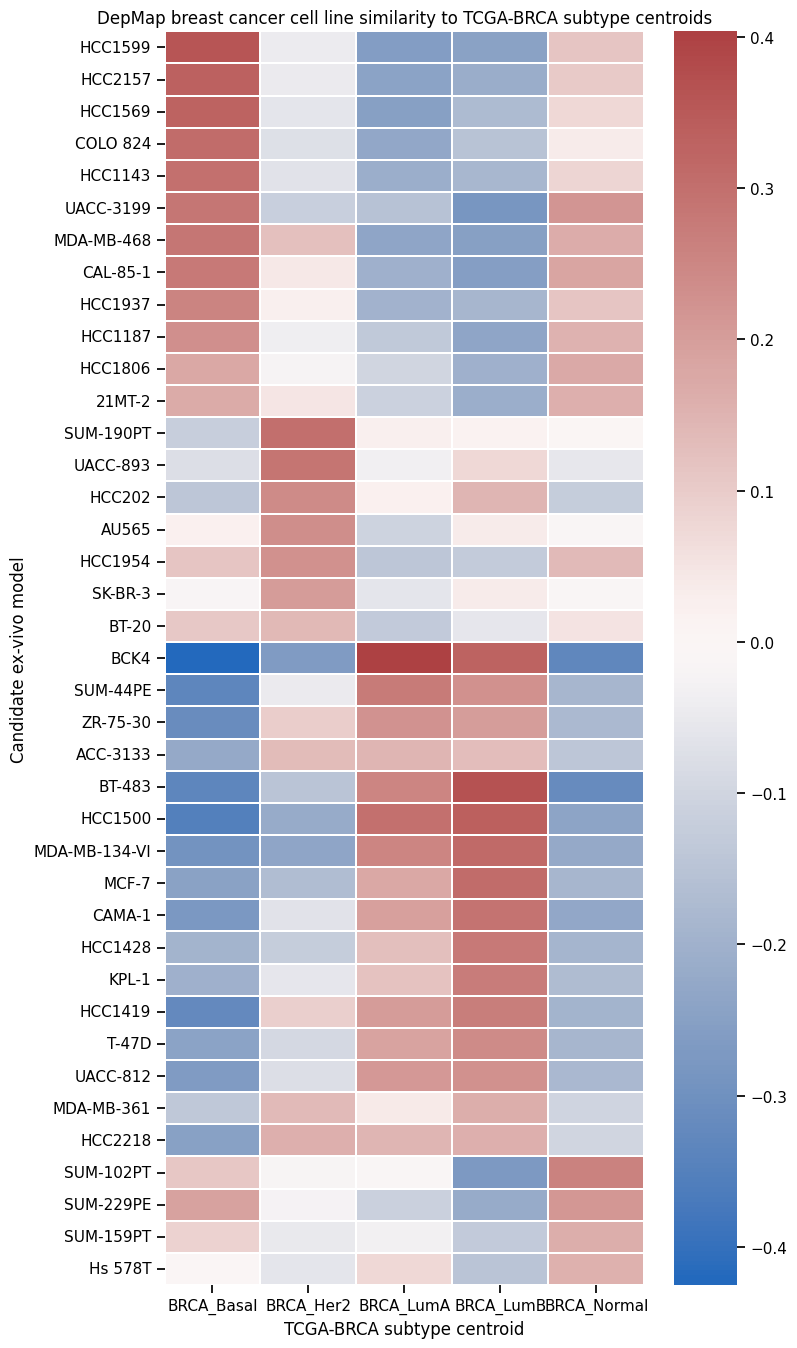

In [40]:
top_unique_models = (
    top_matches_df[name_col]
    .drop_duplicates()
    .tolist()
)

plot_df = merged_similarity[merged_similarity[name_col].isin(top_unique_models)].copy()

heatmap_df = plot_df.set_index(name_col)[subtype_cols]

# Order by best matching subtype and similarity
plot_df_ordered = plot_df.sort_values(
    ["best_matching_tcga_subtype", "best_similarity"],
    ascending=[True, False]
)

heatmap_df = plot_df_ordered.set_index(name_col)[subtype_cols]

plt.figure(figsize=(8, max(6, 0.35 * heatmap_df.shape[0])))

sns.heatmap(
    heatmap_df,
    cmap="vlag",
    center=0,
    linewidths=0.2,
)

plt.title("DepMap breast cancer cell line similarity to TCGA-BRCA subtype centroids")
plt.xlabel("TCGA-BRCA subtype centroid")
plt.ylabel("Candidate ex-vivo model")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "depmap_breast_models_tcga_subtype_similarity_heatmap.png",
    dpi=300,
)

plt.show()

In [41]:
similarity_values = merged_similarity[subtype_cols].copy()

merged_similarity["best_matching_tcga_subtype"] = similarity_values.idxmax(axis=1)
merged_similarity["best_similarity"] = similarity_values.max(axis=1)
merged_similarity["second_best_similarity"] = similarity_values.apply(
    lambda row: row.sort_values(ascending=False).iloc[1],
    axis=1
)
merged_similarity["similarity_margin"] = (
    merged_similarity["best_similarity"] - merged_similarity["second_best_similarity"]
)

cols_to_show = [
    name_col,
    "ModelID",
    "ModelSubtypeFeatures",
    "best_matching_tcga_subtype",
    "best_similarity",
    "second_best_similarity",
    "similarity_margin",
]

cols_to_show = [c for c in cols_to_show if c in merged_similarity.columns]

display(
    merged_similarity
    .sort_values("similarity_margin", ascending=False)[cols_to_show]
    .head(30)
)

,CellLineName,ModelID,ModelSubtypeFeatures,best_matching_tcga_subtype,best_similarity,second_best_similarity,similarity_margin
55,SUM-190PT,ACH-001393,basal_A HER2+,BRCA_Her2,0.302240,0.027112,0.275128
64,COLO 824,ACH-001820,HER2+,BRCA_Basal,0.309695,0.035599,0.274096
48,HCC1569,ACH-000930,basal_A HER2+,BRCA_Basal,0.331199,0.074129,0.257070
9,HCC1599,ACH-000196,basal_A TNBC,BRCA_Basal,0.360670,0.113641,0.247030
29,HCC2157,ACH-000691,basal_A TNBC,BRCA_Basal,0.333514,0.104318,0.229196
20,HCC1143,ACH-000374,basal_A TNBC,BRCA_Basal,0.296871,0.082163,0.214708
22,UACC-893,ACH-000554,HER2+,BRCA_Her2,0.289096,0.075626,0.213469
12,AU565,ACH-000248,HER2+,BRCA_Her2,0.234199,0.037463,0.196737
0,SK-BR-3,ACH-000017,HER2+,BRCA_Her2,0.202957,0.036324,0.166633
2,KPL-1,ACH-000028,ER+,BRCA_LumB,0.272283,0.119078,0.153205


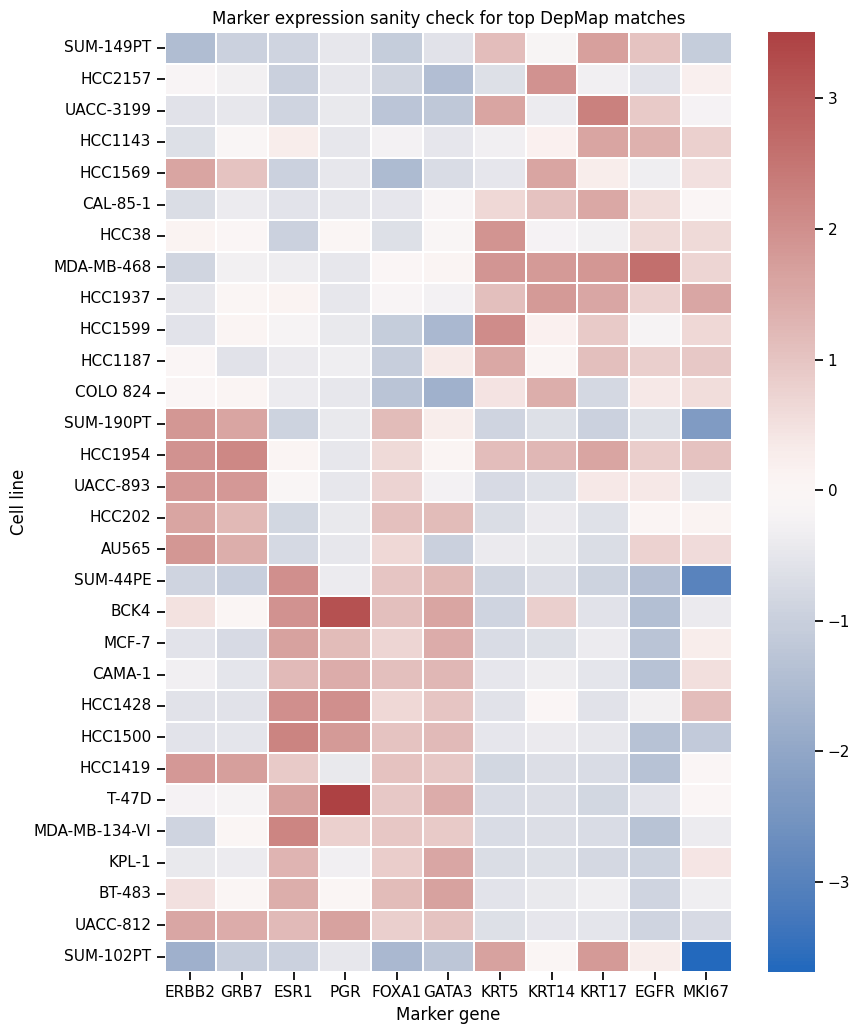

In [42]:
marker_genes = [
    "ERBB2", "GRB7",
    "ESR1", "PGR", "FOXA1", "GATA3",
    "KRT5", "KRT14", "KRT17", "EGFR",
    "MKI67"
]

marker_genes = [g for g in marker_genes if g in dep_breast_expr.columns]

marker_df = dep_breast_expr[marker_genes].copy()
marker_df = (marker_df - marker_df.mean(axis=0)) / marker_df.std(axis=0)

marker_df = marker_df.merge(
    merged_similarity[[name_col, "ModelID", "best_matching_tcga_subtype"]],
    left_index=True,
    right_on="ModelID",
    how="inner"
)

top_for_plot = (
    merged_similarity
    .sort_values("best_similarity", ascending=False)
    .head(30)["ModelID"]
    .tolist()
)

plot_markers = marker_df[marker_df["ModelID"].isin(top_for_plot)].copy()
plot_markers = plot_markers.sort_values("best_matching_tcga_subtype")

heatmap_markers = plot_markers.set_index(name_col)[marker_genes]

plt.figure(figsize=(9, max(5, 0.35 * heatmap_markers.shape[0])))
sns.heatmap(
    heatmap_markers,
    cmap="vlag",
    center=0,
    linewidths=0.2
)
plt.title("Marker expression sanity check for top DepMap matches")
plt.xlabel("Marker gene")
plt.ylabel("Cell line")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "depmap_top_matches_marker_sanity_check.png",
    dpi=300
)
plt.show()

## Preliminary interpretation

This proof-of-concept analysis projects TCGA-BRCA molecular subtype expression profiles onto DepMap/CCLE breast cancer cell lines.

The goal is to prioritize candidate ex-vivo models that transcriptionally resemble Basal-like, HER2-enriched, Luminal-like or Normal-like TCGA-BRCA tumour contexts.

Results should be interpreted cautiously because cell lines do not capture tumour microenvironment, immune composition, stromal content or patient-level heterogeneity. This model matching is intended as a hypothesis-generating prioritization step, not as experimental validation.